## Chapter 2: Making the Sampling Differentiable

In the MC algorithm, the first step is to sample a photon count $n$ from a normal distribution $\mathcal{N}(\bar{n}, \sigma)$. This is straightforward in a classical simulation:

$$n \sim \mathcal{N}(\bar{n}, \sigma)$$

However, $n$ must be an integer (you can't detect half a photon), so we round:

$$n = \text{round}(\bar{n} + \sigma \cdot \varepsilon), \quad \varepsilon \sim \mathcal{N}(0,1)$$

This is where differentiability breaks down. Both the random sampling and the rounding are non-differentiable operations — they have no gradient with respect to the parameters $(\bar{n}, \sigma)$.

If we want to optimize $(\bar{n}, \sigma)$ via gradient descent, we need gradients of the loss with respect to these parameters. The random sampling blocks the gradient because it's a stochastic node. The rounding blocks it because it's a step function (gradient is zero almost everywhere).

In this chapter, we will build up the tools to solve this, starting with a **simple example** where the underlying process is clear. We will show how to:

1. Make the random sampling differentiable using the **reparameterization trick**
2. Handle the rounding using **Straight-Through Estimator (STE)** or similar approximations
3. Verify that gradients flow correctly through the pipeline

Once we understand these building blocks, we will apply them to the full MC simulation in the next chapters.

---

### Conclusion: The Two Strategies

#### 1. Reparameterization Trick

Instead of sampling $n \sim \mathcal{N}(\mu, \sigma)$ directly (a stochastic node with no gradient), we separate the randomness:

$$\varepsilon \sim \mathcal{N}(0, 1), \quad n = \mu + \sigma \cdot \varepsilon \quad \Longrightarrow \quad \frac{dn}{d\mu} = 1$$

The randomness is isolated in $\varepsilon$, which we keep fixed during the gradient step. The gradient path becomes $dL/d\mu = dL/dn \cdot dn/d\mu = dL/dn$.

#### 2. Finite Difference Surrogate Gradient

The discrete for-loop (or any non-differentiable operation) blocks autograd. We estimate the gradient by probing the loss at neighboring points:

$$\frac{dL}{dn} \approx \frac{L(n+1) - L(n-1)}{2}$$

This is a **finite difference surrogate gradient** — "finite difference" because we use numerical differences, and "surrogate" because it replaces a true gradient that doesn't exist. As long as we can evaluate the loss function, we can probe it at $n \pm 1$ and get a gradient estimate, regardless of how complex or non-differentiable the forward pass is.

**The complete pipeline:**

```
μ → reparameterization → n → discrete for-loop → x → loss
    (differentiable)           (not differentiable)
                                      ↓
                         finite difference surrogate gradient
                         probes L(n+1) and L(n-1)
```

This approach is general: it works for any non-differentiable forward pass, including the full MC simulation in the paper.

---


Final mu = 50.20  (target = 50)

First 5 steps:
  step 0: mu=14.00, n=10, loss=1600, grad=-80.00
  step 1: mu=17.60, n=14, loss=1296, grad=-72.00
  step 2: mu=20.80, n=18, loss=1024, grad=-64.00
  step 3: mu=23.70, n=21, loss=841, grad=-58.00
  step 4: mu=26.40, n=23, loss=729, grad=-54.00

Last 5 steps:
  step 195: mu=50.00, n=51, loss=1, grad=2.00
  step 196: mu=50.00, n=50, loss=0, grad=0.00
  step 197: mu=50.10, n=49, loss=1, grad=-2.00
  step 198: mu=50.10, n=50, loss=0, grad=0.00
  step 199: mu=50.20, n=49, loss=1, grad=-2.00


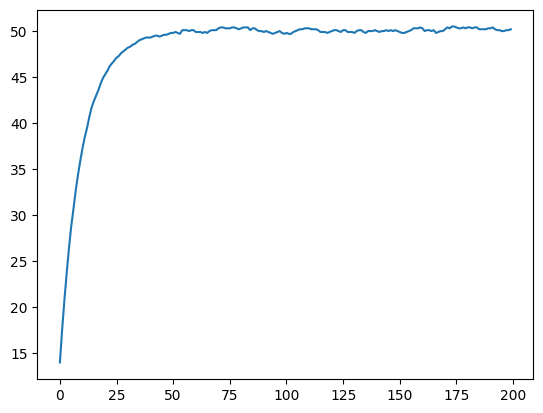

In [13]:
# === Chapter 2: Simple Example — Finite Difference Surrogate Gradient ===

import torch
import math
import matplotlib.pyplot as plt

# Setup
mu = torch.tensor([10.0])       # initial guess
sigma = 1.0                     # fixed
target = 50
lr = 0.05
num_steps = 200

torch.manual_seed(42)
history = []

for step in range(num_steps):
    # 1. Reparameterized sample
    epsilon = torch.randn(1).item()
    n = round(mu.item() + sigma * epsilon)
    n = max(n, 0)  # no negative photons

    # 2. Non-differentiable forward pass (for-loop)
    x = 0
    for _ in range(n):
        x += 1

    # 3. Loss
    loss = (x - target) ** 2

    # 4. Finite difference surrogate gradient
    x_plus = 0
    for _ in range(n + 1):
        x_plus += 1
    loss_plus = (x_plus - target) ** 2

    x_minus = 0
    for _ in range(max(0, n - 1)):
        x_minus += 1
    loss_minus = (x_minus - target) ** 2

    grad = (loss_plus - loss_minus) / 2.0

    # 5. Gradient descent step
    mu -= lr * grad

    history.append((step, mu.item(), n, loss, grad))

# Results
print(f"Final mu = {mu.item():.2f}  (target = {target})")
print(f"\nFirst 5 steps:")
for s, m, n, l, g in history[:5]:
    print(f"  step {s}: mu={m:.2f}, n={n}, loss={l:.0f}, grad={g:.2f}")
print(f"\nLast 5 steps:")
for s, m, n, l, g in history[-5:]:
    print(f"  step {s}: mu={m:.2f}, n={n}, loss={l:.0f}, grad={g:.2f}")

plt.plot([mu[1] for mu in history])